# GPC productType → MiDiffusion category mapping

**Goal**: Map every distinct GPC `productType` (~1900 values) to one of ~50 target furniture categories used to train MiDiffusion.

**Approach**: For each productType, sample N=12 representative products from the live GPC catalogue, build a tiled image of their thumbnails + names, and ask Gemini 2.5 Flash multimodal to classify the *productType as a whole* into one of the target categories. Each call also returns a confidence and a short reason.

**Inputs**:
- BQ table `ingka-hip-productbundles-dev.Bundle.item_data_available` (productType + thumb_url + metadata)
- Billing project: `ingka-b2bda-iifb-test`
- Vertex AI: `gemini-2.5-flash` in `europe-west4`

**Outputs**:
- `outputs/productType_mapping.csv` — one row per productType with the assigned category, confidence, reason, and a sample of product IDs.
- `outputs/productType_distribution.csv` — productType frequencies (raw GPC stats).
- `outputs/cards/<productType>.png` — debug tiles per productType.

**Conventions borrowed from** `b2bda-ifb-studior2b/.../core/vlm_selector.py` and `core/image_utils.py`.


## 1. Setup


In [1]:
from __future__ import annotations

import json
import logging
import os
import random
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from io import BytesIO
from pathlib import Path
from typing import Optional

import pandas as pd
import requests
from google.cloud import bigquery, storage
from PIL import Image, ImageDraw, ImageFont

import vertexai
from vertexai.generative_models import GenerativeModel, Part, GenerationConfig

logging.basicConfig(level=logging.INFO, format="%(asctime)s  %(levelname)-7s  %(message)s")
log = logging.getLogger("gpc_map")

# ---------- config ----------
BQ_BILLING_PROJECT = "ingka-b2bda-iifb-test"
# This is the Geomagical / Blinka catalogue table — single source for productType + name + thumb_url + sellability.
BQ_GPC_TABLE       = "ingka-explainableai-tpu-dev.Bundle.item_data_available"

VERTEX_PROJECT  = "ingka-b2bda-iifb-test"
VERTEX_LOCATION = "europe-west4"
VERTEX_MODEL    = "gemini-2.5-flash"

GCS_BUCKET      = "ingka-b2b-da-ifb-test-studior2b"
GCS_PREFIX      = "gpc_taxonomy_mapping"

REGION_FILTER   = "gb/en"   # restrict to one region to avoid product duplicates across markets
N_SAMPLES       = 12        # products sampled per productType
SEED            = 42
random.seed(SEED)

OUT_DIR  = Path.cwd().parent / "outputs" / "gpc_taxonomy_mapping"
OUT_DIR.mkdir(parents=True, exist_ok=True)
CARDS_DIR = OUT_DIR / "cards"
CARDS_DIR.mkdir(parents=True, exist_ok=True)
IMG_CACHE = OUT_DIR / "img_cache"
IMG_CACHE.mkdir(parents=True, exist_ok=True)

PATH_TYPES_CSV     = OUT_DIR / "productType_distribution.csv"
PATH_SAMPLES_PARQ  = OUT_DIR / "productType_samples.parquet"
PATH_MAPPING_CSV   = OUT_DIR / "productType_mapping.csv"
PATH_CATEGORIES    = OUT_DIR / "target_categories.json"

print("output dir:", OUT_DIR)


output dir: /Users/carlos.soto1/Projects/BLINKA/MiDiffusion/outputs/gpc_taxonomy_mapping


## 2. Target category vocabulary

Drafted from the reference MiDiffusion vocabularies (bedroom 21, living/dining 24, library 27 — union ≈ 35 unique) plus IKEA-specific additions to cover GPC's broader catalogue. Aim for ~50 final classes. A `__none__` slot is reserved for "this productType isn't furniture we want to model" (rugs, curtains, decor, plants, etc.).


In [2]:
TARGET_CATEGORIES: dict[str, str] = {
    # ---- seating ----
    "armchair":            "single upholstered chair with arms, lounge or living-room style",
    "dining_chair":        "single hard chair intended for a dining/work table",
    "office_chair":        "swivel/wheeled task or office chair",
    "lounge_chair":        "low recliner-style or accent lounge chair without sofa form-factor",
    "stool":               "stool, footstool, ottoman or pouffe (no back, low height)",
    "bar_stool":           "tall bar/counter stool (with or without back)",
    "bench":               "long bench for seating (dining or hallway)",
    "kids_chair":          "chair sized for children",
    # ---- sofas ----
    "sofa_2_seat":         "loveseat / two-seater sofa",
    "sofa_3_seat":         "three-seat or larger straight sofa",
    "sofa_l_shaped":       "L-shaped, sectional, corner or chaise-longue sofa",
    "sofa_bed":            "convertible sofa that opens into a bed",
    # ---- beds ----
    "bed_single":          "single-size bed frame (incl. day bed)",
    "bed_double":          "double, queen or king bed frame",
    "bed_kids":            "kids bed, toddler bed, bunk bed, loft bed",
    "crib":                "baby cot / crib",
    "mattress":            "standalone mattress (no frame)",
    # ---- tables ----
    "dining_table":        "dining or kitchen table",
    "coffee_table":        "low coffee / cocktail table in front of a sofa",
    "side_table":          "side / end / nightstand-style small table",
    "console_table":       "narrow console / hallway / sofa-back table",
    "desk":                "desk / writing table / workstation",
    "bar_table":           "tall bar / counter-height table",
    "kids_table":          "table sized for children",
    "outdoor_table":       "outdoor/garden table",
    # ---- storage (case goods) ----
    "wardrobe":            "wardrobe / armoire (tall closed clothing storage)",
    "chest_of_drawers":    "chest of drawers / dresser (low, drawer-only)",
    "nightstand":          "bedside table / nightstand (specifically beside a bed)",
    "bookshelf":           "open bookshelf / open shelving unit",
    "shelf_unit":          "wall shelf / floating shelf / small shelving accessory",
    "cabinet":             "general closed cabinet (sideboard, buffet, storage cabinet)",
    "tv_unit":             "TV bench / media unit",
    "shoe_cabinet":        "shoe rack or shoe cabinet",
    "kitchen_cabinet":     "kitchen base / wall / tall cabinet",
    "kitchen_island":      "kitchen island / kitchen worktop unit",
    "filing_cabinet":      "office filing cabinet / drawer pedestal",
    "storage_combination": "modular storage combination (shelves with boxes/doors)",
    # ---- bathroom ----
    "bathroom_vanity":     "bathroom sink cabinet / vanity / washstand",
    "bathroom_storage":    "bathroom cabinet, mirror cabinet, bathroom shelf",
    # ---- soft / textiles & lighting (kept narrow on purpose) ----
    "ceiling_lamp":        "ceiling-mounted lamp / chandelier / pendant",
    "floor_lamp":          "floor-standing lamp",
    "table_lamp":          "table or desk lamp",
    "wall_lamp":           "wall-mounted lamp / sconce",
    "mirror":              "wall or floor mirror",
    # ---- outdoor / misc furniture we still place ----
    "outdoor_chair":       "outdoor / garden chair or lounger",
    "outdoor_sofa":        "outdoor / garden sofa or sectional",
    "outdoor_storage":     "outdoor storage box / shed cabinet",
    "room_divider":        "room divider / partition / screen",
    "coat_rack":           "coat rack / hat stand / hallway hook unit",
    # ---- explicit drop ----
    "__none__":            "NOT a placeable furniture object (rugs, curtains, decor, plants, textiles, kitchenware, plates, small appliances, picture frames, cushions, candles, etc.)",
}

print(f"{len(TARGET_CATEGORIES)} target categories (incl. __none__)")
PATH_CATEGORIES.write_text(json.dumps(TARGET_CATEGORIES, indent=2))
print("saved:", PATH_CATEGORIES)


50 target categories (incl. __none__)
saved: /Users/carlos.soto1/Projects/BLINKA/MiDiffusion/outputs/gpc_taxonomy_mapping/target_categories.json


## 3. Pull productType distribution

One BQ query: distinct `typeName`s in the GPC bundle table, plus a count of distinct `localItemNumber`s per type, restricted to `gb/en` and online-sellable products. Result cached to CSV so we don't re-hit BQ on reruns.


In [3]:
bq = bigquery.Client(project=BQ_BILLING_PROJECT)

if PATH_TYPES_CSV.exists():
    types_df = pd.read_csv(PATH_TYPES_CSV)
    log.info("loaded cached productType distribution: %d rows", len(types_df))
else:
    sql = f"""
    SELECT
      typeName AS productType,
      COUNT(*) AS n_items,
      COUNTIF(thumb_url IS NOT NULL) AS n_items_with_img
    FROM `{BQ_GPC_TABLE}`
    WHERE region = @region
      AND online_sellable = TRUE
      AND is_available    = TRUE
      AND typeName IS NOT NULL
    GROUP BY typeName
    ORDER BY n_items DESC
    """
    job_config = bigquery.QueryJobConfig(
        query_parameters=[bigquery.ScalarQueryParameter("region", "STRING", REGION_FILTER)]
    )
    types_df = bq.query(sql, job_config=job_config).to_dataframe()
    types_df.to_csv(PATH_TYPES_CSV, index=False)
    log.info("fetched productType distribution: %d rows -> %s", len(types_df), PATH_TYPES_CSV)

print("total productTypes:", len(types_df))
print("total items       :", int(types_df.n_items.sum()))
print("items w/ thumb_url:", int(types_df.n_items_with_img.sum()))
types_df.head(15)


/Users/carlos.soto1/Projects/BLINKA/MiDiffusion/.venv/lib/python3.13/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
/Users/carlos.soto1/Projects/BLINKA/MiDiffusion/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
2026-05-22 12:49:24,612  INFO     fetched productType distribution: 1308 rows -> /Users/carlos.soto1/Projects/BLINKA/MiDiffusion/outputs/gpc_taxonomy_mapping/productType_distribution.csv


total productTypes: 1308
total items       : 8691
items w/ thumb_url: 8672


,productType,n_items,n_items_with_img
0,desk,197,197
1,storage combination with boxes,187,187
2,wardrobe combination,150,150
3,frame,139,139
4,wall-mounted cabinet combination,136,136
5,3-seat sofa,128,125
6,armchair,126,126
7,chair,119,119
8,storage combination with doors,109,109
9,shelving unit,107,107


## 4. Sample N items per productType

For each productType, pull up to `N_SAMPLES` (item_no, name, thumb_url) rows where the thumbnail is available. Single-query approach using `ROW_NUMBER()` to keep BQ traffic to one round-trip.


In [4]:
if PATH_SAMPLES_PARQ.exists():
    samples_df = pd.read_parquet(PATH_SAMPLES_PARQ)
    log.info("loaded cached samples: %d rows", len(samples_df))
else:
    sql = f"""
    WITH src AS (
      SELECT
        typeName AS productType,
        localItemNumber AS item_no,
        name,
        thumb_url,
        FARM_FINGERPRINT(CONCAT(typeName, '|', localItemNumber, '|', CAST(@seed AS STRING))) AS shuf
      FROM `{BQ_GPC_TABLE}`
      WHERE region = @region
        AND online_sellable = TRUE
        AND is_available    = TRUE
        AND typeName IS NOT NULL
        AND thumb_url IS NOT NULL
    ),
    ranked AS (
      SELECT *, ROW_NUMBER() OVER (PARTITION BY productType ORDER BY shuf) AS rn
      FROM src
    )
    SELECT productType, item_no, name, thumb_url, rn
    FROM ranked
    WHERE rn <= @n
    ORDER BY productType, rn
    """
    job_config = bigquery.QueryJobConfig(query_parameters=[
        bigquery.ScalarQueryParameter("region", "STRING", REGION_FILTER),
        bigquery.ScalarQueryParameter("n", "INT64", N_SAMPLES),
        bigquery.ScalarQueryParameter("seed", "INT64", SEED),
    ])
    samples_df = bq.query(sql, job_config=job_config).to_dataframe()
    samples_df.to_parquet(PATH_SAMPLES_PARQ, index=False)
    log.info("fetched samples: %d rows -> %s", len(samples_df), PATH_SAMPLES_PARQ)

per_type = samples_df.groupby("productType").size()
print("productTypes covered :", len(per_type))
print("avg samples per type :", per_type.mean().round(2))
print("min samples per type :", per_type.min())
print("types w/ <4 samples  :", (per_type < 4).sum())
samples_df.head(8)


/Users/carlos.soto1/Projects/BLINKA/MiDiffusion/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
2026-05-22 12:49:50,234  INFO     fetched samples: 4727 rows -> /Users/carlos.soto1/Projects/BLINKA/MiDiffusion/outputs/gpc_taxonomy_mapping/productType_samples.parquet


productTypes covered : 1303
avg samples per type : 3.63
min samples per type : 1
types w/ <4 samples  : 902


,productType,item_no,name,thumb_url,rn
0,1 sec/foldable table/sliding door,69469518,IVAR,https://www.ikea.com/gb/en/images/products/iva...,1
1,1 sec/storage unit w foldable table,79469527,IVAR,https://www.ikea.com/gb/en/images/products/iva...,1
2,1 section,79031414,HEJNE,https://www.ikea.com/gb/en/images/products/hej...,1
3,1 section,39031411,HEJNE,https://www.ikea.com/gb/en/images/products/hej...,2
4,1 section,89590599,IVAR,https://www.ikea.com/gb/en/images/products/iva...,3
5,1 section/bottle racks,89403814,IVAR,https://www.ikea.com/gb/en/images/products/iva...,1
6,1 section/shelves,79407054,IVAR,https://www.ikea.com/gb/en/images/products/iva...,1
7,1 section/shelves,29403845,IVAR,https://www.ikea.com/gb/en/images/products/iva...,2


## 5. Image fetch + composite tile builder

- Disk cache under `outputs/.../img_cache/<item_no>.jpg` so reruns are cheap.
- Composite: up to 12 thumbs in a 4-col grid, label below each tile with item_no + name. One PNG per productType, saved under `outputs/.../cards/`.


2026-05-22 12:50:19,623  WARNING  Connection pool is full, discarding connection: www.ikea.com. Connection pool size: 10
2026-05-22 12:50:19,945  WARNING  Connection pool is full, discarding connection: www.ikea.com. Connection pool size: 10


sanity card: /Users/carlos.soto1/Projects/BLINKA/MiDiffusion/outputs/gpc_taxonomy_mapping/cards/armchair.png tiles used: 12


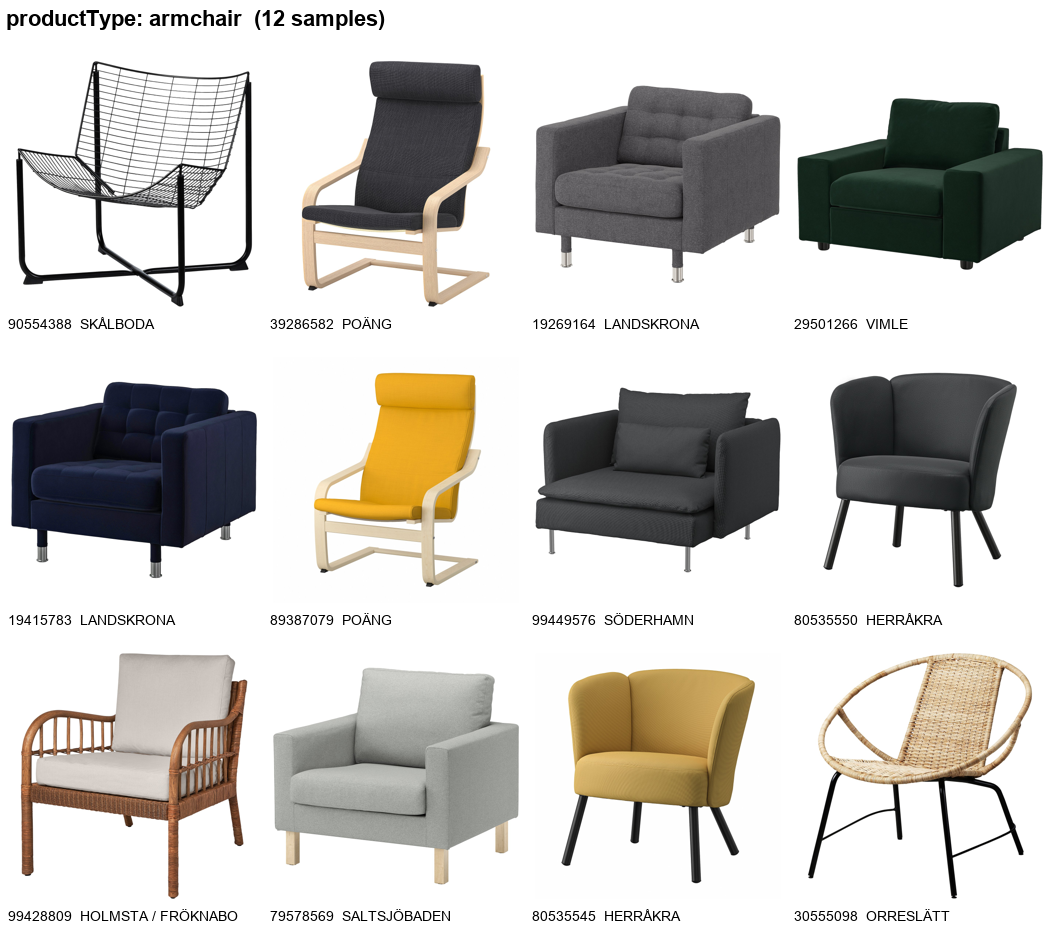

In [5]:
_HTTP = requests.Session()
_HTTP.headers.update({"User-Agent": "midiffusion-gpc-map/1.0"})

TILE_W, TILE_H = 256, 256
LABEL_H        = 34
GRID_COLS      = 4
PAD            = 6
HEADER_H       = 56

try:
    _FONT       = ImageFont.truetype("/System/Library/Fonts/Supplemental/Arial.ttf", 14)
    _FONT_HEAD  = ImageFont.truetype("/System/Library/Fonts/Supplemental/Arial Bold.ttf", 22)
except Exception:
    _FONT      = ImageFont.load_default()
    _FONT_HEAD = ImageFont.load_default()


def _safe_name(s: str) -> str:
    return "".join(c if c.isalnum() or c in "-_." else "_" for c in s)[:120]


def fetch_image(item_no: str, url: str, *, timeout: float = 10.0) -> Optional[Image.Image]:
    cache = IMG_CACHE / f"{item_no}.jpg"
    if cache.exists() and cache.stat().st_size > 0:
        try:
            return Image.open(cache).convert("RGB")
        except Exception:
            cache.unlink(missing_ok=True)
    try:
        r = _HTTP.get(url, timeout=timeout)
        r.raise_for_status()
        img = Image.open(BytesIO(r.content)).convert("RGB")
        img.save(cache, "JPEG", quality=85)
        return img
    except Exception as exc:
        log.debug("fetch failed item=%s: %s", item_no, exc)
        return None


def fetch_many(rows: pd.DataFrame, *, max_workers: int = 16) -> dict[str, Image.Image]:
    out: dict[str, Image.Image] = {}
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        fut = {ex.submit(fetch_image, r.item_no, r.thumb_url): r.item_no for r in rows.itertuples()}
        for f in as_completed(fut):
            it = fut[f]
            img = f.result()
            if img is not None:
                out[it] = img
    return out


def build_card(product_type: str, rows: pd.DataFrame) -> tuple[Path, int]:
    """Build a composite PNG for one productType. Returns (path, n_tiles_actually_used)."""
    imgs = fetch_many(rows)
    used = [r for r in rows.itertuples() if r.item_no in imgs]
    if not used:
        raise RuntimeError(f"no images fetched for productType={product_type!r}")

    n  = len(used)
    cols = min(GRID_COLS, n)
    rows_n = (n + cols - 1) // cols
    cell_w = TILE_W + PAD
    cell_h = TILE_H + LABEL_H + PAD
    W = cols * cell_w + PAD
    H = HEADER_H + rows_n * cell_h + PAD

    canvas = Image.new("RGB", (W, H), "white")
    draw   = ImageDraw.Draw(canvas)
    draw.text((PAD, PAD), f"productType: {product_type}  ({n} samples)", fill="black", font=_FONT_HEAD)

    for i, r in enumerate(used):
        col = i % cols
        row = i // cols
        x = PAD + col * cell_w
        y = HEADER_H + row * cell_h
        thumb = imgs[r.item_no].copy()
        thumb.thumbnail((TILE_W, TILE_H))
        tx = x + (TILE_W - thumb.width)  // 2
        ty = y + (TILE_H - thumb.height) // 2
        canvas.paste(thumb, (tx, ty))
        label = f"{r.item_no}  {str(r.name)[:22]}"
        draw.text((x + 2, y + TILE_H + 4), label, fill="black", font=_FONT)

    out = CARDS_DIR / f"{_safe_name(product_type)}.png"
    canvas.save(out, "PNG", optimize=True)
    return out, n


# --- quick sanity: build a card for one well-known type ---
sample_pt = "armchair"
rows = samples_df[samples_df.productType == sample_pt]
path, used = build_card(sample_pt, rows)
print("sanity card:", path, "tiles used:", used)
Image.open(path)


## 6. Gemini multimodal classifier

One call per productType. Sends:
1. the composite card (image),
2. the productType string + product names,
3. the target-category vocabulary with definitions.

Asks for JSON: `{category, confidence, reason}`. We retry on transient errors and parse defensively. Results stream into `PATH_MAPPING_CSV` so a crash mid-run doesn't lose work.


In [11]:
vertexai.init(project=VERTEX_PROJECT, location=VERTEX_LOCATION)
model = GenerativeModel(VERTEX_MODEL)

_CAT_BLOCK = "\n".join(f"- {k}: {v}" for k, v in TARGET_CATEGORIES.items())
_VALID_CATS = set(TARGET_CATEGORIES.keys())

PROMPT_TMPL = """You are a furniture taxonomist mapping IKEA product-type labels to a fixed vocabulary used to train a 3D scene-generation model.

The image below shows up to 12 representative products that all share the same IKEA productType: "{product_type}".
Product names (in tile order): {names}

Pick the SINGLE best matching category from this vocabulary:

{cats}

Rules:
- Pick exactly one category key from the list above. The key must be copied verbatim, lowercase, with underscores.
- If the productType is NOT a piece of placeable furniture (e.g. rugs, curtains, plants, decor, kitchenware, tableware, picture frames, candles, cushions, small accessories, textiles, small appliances), pick "__none__".
- The decision must reflect what the productType *as a whole* represents. Individual outliers in the image grid should be ignored.
- "confidence" is your subjective probability the chosen category is correct (0.0-1.0).
- "reason" is one short sentence (max 20 words) justifying the choice.

Return ONLY a compact JSON object with keys: category, confidence, reason. Keep total response under 60 tokens.
"""

# Bumped to 4096 because gemini-2.5 "thinking" tokens count against this budget and ate the JSON in the first pass.
_GEN_CFG = GenerationConfig(
    temperature=0.0,
    max_output_tokens=4096,
    response_mime_type="application/json",
)


def _img_to_part(path: Path) -> Part:
    return Part.from_data(data=path.read_bytes(), mime_type="image/png")


def classify_one(product_type: str, rows: pd.DataFrame, card_path: Path,
                 *, max_retries: int = 3) -> dict:
    names = ", ".join(str(n) for n in rows["name"].tolist())
    prompt = PROMPT_TMPL.format(product_type=product_type, names=names, cats=_CAT_BLOCK)
    last_err = None
    for attempt in range(max_retries):
        try:
            resp = model.generate_content([_img_to_part(card_path), prompt],
                                          generation_config=_GEN_CFG)
            raw = (resp.text or "").strip()
            obj = json.loads(raw)
            cat = str(obj.get("category", "")).strip()
            conf = float(obj.get("confidence", 0.0))
            reason = str(obj.get("reason", "")).strip()
            if cat not in _VALID_CATS:
                raise ValueError(f"invalid category {cat!r}")
            return {"category": cat, "confidence": conf, "reason": reason, "raw": raw}
        except Exception as exc:  # noqa: BLE001
            last_err = exc
            time.sleep(1.5 * (attempt + 1))
    return {"category": "__error__", "confidence": 0.0,
            "reason": f"{type(last_err).__name__}: {last_err}", "raw": ""}


# --- sanity: one call on the armchair card we built earlier ---
_sanity = classify_one("armchair", samples_df[samples_df.productType == "armchair"],
                       CARDS_DIR / "armchair.png")
print(_sanity)


/Users/carlos.soto1/Projects/BLINKA/MiDiffusion/.venv/lib/python3.13/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


{'category': 'armchair', 'confidence': 1.0, 'reason': "The product type is explicitly 'armchair' and the items fit the definition of a single upholstered chair with arms.", 'raw': '{"category": "armchair", "confidence": 1.0, "reason": "The product type is explicitly \'armchair\' and the items fit the definition of a single upholstered chair with arms."}'}


## 7. Run on every productType

Build the card if it doesn't already exist, then classify. Skip productTypes that are already in `PATH_MAPPING_CSV`. Parallel image fetching is inside `build_card`; classifier calls run in a thread pool. Results stream to CSV after every batch.


In [12]:
def _load_done() -> set[str]:
    if not PATH_MAPPING_CSV.exists():
        return set()
    df = pd.read_csv(PATH_MAPPING_CSV)
    return set(df.loc[df["category"] != "__error__", "productType"].astype(str))


def _append_rows(rows: list[dict]) -> None:
    if not rows:
        return
    df = pd.DataFrame(rows)
    header = not PATH_MAPPING_CSV.exists()
    df.to_csv(PATH_MAPPING_CSV, mode="a", index=False, header=header)


def _process_one(product_type: str) -> dict:
    rows = samples_df[samples_df.productType == product_type]
    if rows.empty:
        return {"productType": product_type, "n_samples": 0, "category": "__error__",
                "confidence": 0.0, "reason": "no samples", "item_nos": "", "names": ""}
    safe = _safe_name(product_type)
    card = CARDS_DIR / f"{safe}.png"
    try:
        if not card.exists():
            card, _ = build_card(product_type, rows)
    except Exception as exc:  # noqa: BLE001
        return {"productType": product_type, "n_samples": int(len(rows)),
                "category": "__error__", "confidence": 0.0,
                "reason": f"card build failed: {exc}",
                "item_nos": ",".join(rows.item_no.astype(str)),
                "names": " | ".join(rows.name.astype(str))}

    res = classify_one(product_type, rows, card)
    return {
        "productType": product_type,
        "n_samples": int(len(rows)),
        "category": res["category"],
        "confidence": res["confidence"],
        "reason": res["reason"],
        "item_nos": ",".join(rows.item_no.astype(str)),
        "names": " | ".join(rows.name.astype(str)),
    }


def run_all(max_workers: int = 6, batch: int = 25):
    done = _load_done()
    all_types = list(samples_df["productType"].drop_duplicates())
    todo = [t for t in all_types if t not in done]
    log.info("classify: %d done, %d todo, total %d", len(done), len(todo), len(all_types))

    pending: list[dict] = []
    t0 = time.time()
    n_done_run = 0
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futs = {ex.submit(_process_one, t): t for t in todo}
        for f in as_completed(futs):
            row = f.result()
            pending.append(row)
            n_done_run += 1
            if len(pending) >= batch:
                _append_rows(pending); pending = []
                rate = n_done_run / max(time.time() - t0, 1e-3)
                log.info("progress: %d/%d (%.1f/s) last=%r -> %s (%.2f)",
                         n_done_run, len(todo), rate,
                         row["productType"][:40], row["category"], row["confidence"])
    _append_rows(pending)
    log.info("done in %.1fs", time.time() - t0)


run_all(max_workers=6, batch=25)


2026-05-22 13:29:45,352  INFO     classify: 1180 done, 123 todo, total 1303
2026-05-22 13:30:15,490  INFO     progress: 25/123 (0.8/s) last='changing tbl/bookshelf w 1 shlf ut' -> bookshelf (0.70)
2026-05-22 13:30:37,799  INFO     progress: 50/123 (1.0/s) last='fridge' -> cabinet (0.70)
2026-05-22 13:31:13,180  INFO     progress: 75/123 (0.9/s) last='rocking-chair' -> lounge_chair (0.90)
2026-05-22 13:31:46,153  INFO     progress: 100/123 (0.8/s) last='swivel armchair' -> armchair (0.90)
2026-05-22 13:32:13,528  INFO     done in 148.2s


## 8. Summary + QA

Distribution of assigned categories, error rate, and the lowest-confidence rows (where manual review pays off).


In [13]:
mapping_df = pd.read_csv(PATH_MAPPING_CSV)
# de-dup on productType (latest entry wins)
mapping_df = mapping_df.drop_duplicates(subset=["productType"], keep="last").reset_index(drop=True)
mapping_df.to_csv(PATH_MAPPING_CSV, index=False)

print("rows                 :", len(mapping_df))
print("productTypes covered :", mapping_df.productType.nunique())
print("errors               :", int((mapping_df.category == "__error__").sum()))
print("low confidence (<0.6):", int((mapping_df.confidence < 0.6).sum()))
print()

# category histogram weighted by item count, and by productType count
items_by_type = types_df.set_index("productType")["n_items"]
mapping_df["n_items"] = mapping_df["productType"].map(items_by_type).fillna(0).astype(int)

by_cat = mapping_df.groupby("category").agg(
    n_productTypes=("productType", "nunique"),
    n_items=("n_items", "sum"),
    mean_conf=("confidence", "mean"),
).sort_values("n_items", ascending=False)
print(by_cat.to_string())


rows                 : 1303
productTypes covered : 1303
errors               : 0
low confidence (<0.6): 0

                     n_productTypes  n_items  mean_conf
category                                               
__none__                        536     2305   0.987593
storage_combination              81     1015   0.958025
sofa_l_shaped                    48      480   0.990625
cabinet                          48      422   0.931250
bookshelf                        56      381   0.944643
wardrobe                         29      370   0.977586
desk                             30      360   0.933333
dining_table                     15      298   0.916667
bed_double                       22      257   0.959091
tv_unit                          13      221   0.992308
armchair                         15      205   0.926667
shelf_unit                       46      199   0.919565
stool                            19      174   0.960526
sofa_3_seat                       5      162   0.9600

## 9. Low-confidence review

Show the 30 lowest-confidence mappings with the productType, assigned category, and reason, alongside a link to its debug card. These are the rows most worth a manual sanity-check.


In [14]:
lowc = (mapping_df.sort_values("confidence")
                  .head(30)
                  [["productType", "category", "confidence", "n_items", "reason"]])
lowc["card"] = lowc["productType"].map(lambda p: f"cards/{_safe_name(p)}.png")
lowc.reset_index(drop=True)


,productType,category,confidence,n_items,reason,card
0,gazebo,room_divider,0.6,2,A gazebo defines and partitions an outdoor spa...,cards/gazebo.png
1,gazebo with curtains,room_divider,0.6,1,A gazebo defines and partitions an outdoor spa...,cards/gazebo_with_curtains.png
2,bookshelf speaker floor stand,floor_lamp,0.7,1,"It is a tall, floor-standing object designed t...",cards/bookshelf_speaker_floor_stand.png
3,storage trunk,cabinet,0.7,1,"A storage trunk is a closed storage unit, whic...",cards/storage_trunk.png
4,gaming desk and chair,desk,0.7,1,The product type describes a set of a desk and...,cards/gaming_desk_and_chair.png
5,drying rack,shelf_unit,0.7,1,This drying rack functions as a specialized sh...,cards/drying_rack.png
6,changing tbl/bookshelf w 1 shlf ut,bookshelf,0.7,1,The product is a changing table with integrate...,cards/changing_tbl_bookshelf_w_1_shlf_ut.png
7,laundry basket with lining,cabinet,0.7,1,"A laundry basket is a functional, lidded stora...",cards/laundry_basket_with_lining.png
8,laundry bag with castors,cabinet,0.7,4,"This is a framed, movable storage unit for lau...",cards/laundry_bag_with_castors.png
9,multi-functional child chair/table,kids_chair,0.7,1,The product is a multi-functional item for chi...,cards/multi-functional_child_chair_table.png


## 10. Persist outputs

Save the final, deduplicated `productType_mapping.csv` locally, then upload everything we care about (mapping, distribution, target categories, all per-productType debug cards) to GCS so others can grab the artefacts without rerunning the pipeline.


In [15]:
gcs = storage.Client(project=BQ_BILLING_PROJECT)
bucket = gcs.bucket(GCS_BUCKET)


def _upload(local: Path, *, dest_subpath: str = "") -> str:
    rel = local.relative_to(OUT_DIR)
    blob_name = f"{GCS_PREFIX}/{dest_subpath}{rel}" if dest_subpath else f"{GCS_PREFIX}/{rel}"
    blob = bucket.blob(blob_name)
    blob.upload_from_filename(str(local))
    return f"gs://{GCS_BUCKET}/{blob_name}"


# top-level artefacts
for p in [PATH_MAPPING_CSV, PATH_TYPES_CSV, PATH_CATEGORIES, PATH_SAMPLES_PARQ]:
    uri = _upload(p)
    print("uploaded:", uri)

# all debug cards (parallel)
card_paths = sorted(CARDS_DIR.glob("*.png"))
print(f"\nuploading {len(card_paths)} debug cards...")
with ThreadPoolExecutor(max_workers=16) as ex:
    list(ex.map(_upload, card_paths))
print("cards uploaded.")
print(f"\nAll artefacts at: gs://{GCS_BUCKET}/{GCS_PREFIX}/")


/Users/carlos.soto1/Projects/BLINKA/MiDiffusion/.venv/lib/python3.13/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


uploaded: gs://ingka-b2b-da-ifb-test-studior2b/gpc_taxonomy_mapping/productType_mapping.csv
uploaded: gs://ingka-b2b-da-ifb-test-studior2b/gpc_taxonomy_mapping/productType_distribution.csv
uploaded: gs://ingka-b2b-da-ifb-test-studior2b/gpc_taxonomy_mapping/target_categories.json
uploaded: gs://ingka-b2b-da-ifb-test-studior2b/gpc_taxonomy_mapping/productType_samples.parquet

uploading 1299 debug cards...


2026-05-22 13:33:45,278  WARNING  Connection pool is full, discarding connection: storage.googleapis.com. Connection pool size: 10
2026-05-22 13:33:45,315  WARNING  Connection pool is full, discarding connection: storage.googleapis.com. Connection pool size: 10
2026-05-22 13:33:45,323  WARNING  Connection pool is full, discarding connection: storage.googleapis.com. Connection pool size: 10
2026-05-22 13:33:45,340  WARNING  Connection pool is full, discarding connection: storage.googleapis.com. Connection pool size: 10
2026-05-22 13:33:45,349  WARNING  Connection pool is full, discarding connection: storage.googleapis.com. Connection pool size: 10
2026-05-22 13:33:45,369  WARNING  Connection pool is full, discarding connection: storage.googleapis.com. Connection pool size: 10


cards uploaded.

All artefacts at: gs://ingka-b2b-da-ifb-test-studior2b/gpc_taxonomy_mapping/


## 11. Extend vocabulary for non-furniture items

First pass dropped 536 productTypes (26% of items) into `__none__` because they weren't traditional furniture: rugs, plants, vases, cushions, candles, tableware, cookware, small appliances, etc. MiDiffusion is supposed to place *everything*, so we extend the vocabulary with ~16 new small-object / accessory categories, then re-classify only the previously-`__none__` rows against the extended vocab. Non-`__none__` assignments from the first pass are kept as-is.


In [16]:
# Outputs were moved to ~/Downloads/gpc_taxonomy_mapping. Re-point paths.
OUT_DIR   = Path.home() / "Downloads" / "gpc_taxonomy_mapping"
CARDS_DIR = OUT_DIR / "cards"
IMG_CACHE = OUT_DIR / "img_cache"
PATH_TYPES_CSV    = OUT_DIR / "productType_distribution.csv"
PATH_SAMPLES_PARQ = OUT_DIR / "productType_samples.parquet"
PATH_MAPPING_CSV  = OUT_DIR / "productType_mapping.csv"
PATH_CATEGORIES   = OUT_DIR / "target_categories.json"

EXTRA_CATEGORIES: dict[str, str] = {
    "rug":                 "rug, mat, sheepskin, runner — any soft floor covering",
    "wall_art":            "picture frame, poster, painting, photo, wall decoration, noticeboard",
    "decorative_plant":    "plant pot, planter, potted plant, artificial plant, flower box (any plant container shown filled or empty)",
    "vase":                "vase, jug, carafe used as decor (not for cooking)",
    "candle":              "candle, tealight, scented candle, candle holder, lantern",
    "clock":               "wall clock, table clock, alarm clock",
    "cushion":             "cushion, throw pillow, pillow, pillowcase",
    "bed_linen":           "duvet cover, sheets, pillowcase set, blanket, throw, bedspread (textile only, no frame)",
    "towel":               "towel, hand towel, bath towel, tea towel, napkin (cloth)",
    "tableware":           "plate, bowl, mug, cup, glass, cutlery, serving dish, tray, jug — anything you set on a table to eat or drink from",
    "cookware":            "frying pan, saucepan, pot, wok, oven dish, roasting tin, casserole — for use on hob/oven",
    "kitchen_accessory":   "chopping board, utensil, spatula, ladle, grater, knife, dish drainer, kitchen rail, soap dispenser, chef tools",
    "food_storage":        "jar, tin, food container, bottle, lunch box, spice jar — anything to store food/drink",
    "storage_basket_box":  "basket, storage box, storage bag, organiser, magazine file, laundry basket (free-standing small storage container)",
    "bin":                 "waste bin, pedal bin, recycling bin",
    "small_appliance":     "fridge, freezer, dishwasher, oven, hob, microwave, kettle, coffee maker, blender, speaker, air purifier, extractor hood, fan, vacuum",
    "toy":                 "soft toy, doll, building blocks, play tent, children's play item",
    "pet_furniture":       "cat house, dog bed, pet bowl, pet cushion, scratching post",
    "bathroom_accessory":  "soap dish, toilet brush, toothbrush holder, bathroom set, toilet roll holder",
}

# Build the extended vocabulary used ONLY for re-classifying the previously __none__ rows.
EXTENDED_CATEGORIES = {**{k: v for k, v in TARGET_CATEGORIES.items() if k != "__none__"},
                       **EXTRA_CATEGORIES,
                       "__none__": "truly placeable nothing: paper napkins, cling film, wax crayons, single-use items, gift wrap, batteries, light bulbs, screws, cleaning liquids, spare parts, or anything purely consumable."}

print(f"first-pass vocab : {len(TARGET_CATEGORIES)} classes")
print(f"extra added     : {len(EXTRA_CATEGORIES)}")
print(f"extended vocab  : {len(EXTENDED_CATEGORIES)} classes (incl. __none__)")
PATH_CATEGORIES_V2 = OUT_DIR / "target_categories_v2.json"
PATH_CATEGORIES_V2.write_text(json.dumps(EXTENDED_CATEGORIES, indent=2))
print("saved:", PATH_CATEGORIES_V2)


first-pass vocab : 50 classes
extra added     : 19
extended vocab  : 69 classes (incl. __none__)
saved: /Users/carlos.soto1/Downloads/gpc_taxonomy_mapping/target_categories_v2.json


In [17]:
# Re-classify only the rows that landed in __none__ on pass 1, against the extended vocabulary.
mapping_v1 = pd.read_csv(PATH_MAPPING_CSV)
to_redo = mapping_v1[mapping_v1.category == "__none__"]["productType"].tolist()
log.info("re-classifying %d productTypes against extended vocab", len(to_redo))

_CAT_BLOCK_V2 = "\n".join(f"- {k}: {v}" for k, v in EXTENDED_CATEGORIES.items())
_VALID_V2 = set(EXTENDED_CATEGORIES.keys())

PROMPT_V2 = """You are a furniture/object taxonomist mapping IKEA product-type labels to a fixed vocabulary used to train a 3D scene-generation model.

The image below shows up to 12 representative products that all share the same IKEA productType: "{product_type}".
Product names (in tile order): {names}

Pick the SINGLE best matching category from this vocabulary:

{cats}

Rules:
- Pick exactly one category key from the list above. Copy the key verbatim (lowercase, with underscores).
- The model places EVERY item in a room as a 3D bounding box, so almost nothing should be __none__. Only use __none__ for purely consumable, disposable, or formless items (paper napkins, cling film, screws, batteries, light bulbs, cleaning fluids, gift wrap, spare parts).
- Pick the category that fits the productType as a whole; ignore outliers in the grid.
- "confidence" is your probability the choice is correct (0.0-1.0).
- "reason" is one short sentence (max 20 words).

Return ONLY a compact JSON object with keys: category, confidence, reason. Keep total response under 60 tokens.
"""


def classify_one_v2(product_type: str, rows: pd.DataFrame, card_path: Path,
                    *, max_retries: int = 3) -> dict:
    names = ", ".join(str(n) for n in rows["name"].tolist())
    prompt = PROMPT_V2.format(product_type=product_type, names=names, cats=_CAT_BLOCK_V2)
    last_err = None
    for attempt in range(max_retries):
        try:
            resp = model.generate_content([_img_to_part(card_path), prompt],
                                          generation_config=_GEN_CFG)
            raw = (resp.text or "").strip()
            obj = json.loads(raw)
            cat = str(obj.get("category", "")).strip()
            conf = float(obj.get("confidence", 0.0))
            reason = str(obj.get("reason", "")).strip()
            if cat not in _VALID_V2:
                raise ValueError(f"invalid category {cat!r}")
            return {"category": cat, "confidence": conf, "reason": reason, "raw": raw}
        except Exception as exc:  # noqa: BLE001
            last_err = exc
            time.sleep(1.5 * (attempt + 1))
    return {"category": "__error__", "confidence": 0.0,
            "reason": f"{type(last_err).__name__}: {last_err}", "raw": ""}


def _process_one_v2(product_type: str) -> dict:
    rows = samples_df[samples_df.productType == product_type]
    card = CARDS_DIR / f"{_safe_name(product_type)}.png"
    res  = classify_one_v2(product_type, rows, card)
    return {
        "productType": product_type,
        "n_samples":   int(len(rows)),
        "category":    res["category"],
        "confidence":  res["confidence"],
        "reason":      res["reason"],
        "item_nos":    ",".join(rows.item_no.astype(str)),
        "names":       " | ".join(rows.name.astype(str)),
    }


redo_rows: list[dict] = []
t0 = time.time()
with ThreadPoolExecutor(max_workers=6) as ex:
    futs = {ex.submit(_process_one_v2, t): t for t in to_redo}
    for i, f in enumerate(as_completed(futs), 1):
        redo_rows.append(f.result())
        if i % 50 == 0:
            log.info("v2 progress: %d/%d (%.1f/s)", i, len(to_redo), i/max(time.time()-t0,1e-3))
log.info("v2 done in %.1fs", time.time() - t0)

redo_df = pd.DataFrame(redo_rows)
print(redo_df.category.value_counts().to_string())


2026-05-22 14:31:51,442  INFO     re-classifying 536 productTypes against extended vocab
2026-05-22 14:32:15,212  INFO     v2 progress: 50/536 (2.1/s)
2026-05-22 14:32:40,748  INFO     v2 progress: 100/536 (2.0/s)
2026-05-22 14:33:05,729  INFO     v2 progress: 150/536 (2.0/s)
2026-05-22 14:33:43,709  INFO     v2 progress: 200/536 (1.8/s)
2026-05-22 14:34:13,467  INFO     v2 progress: 250/536 (1.8/s)
2026-05-22 14:34:35,650  INFO     v2 progress: 300/536 (1.8/s)
2026-05-22 14:35:02,574  INFO     v2 progress: 350/536 (1.8/s)
2026-05-22 14:35:23,666  INFO     v2 progress: 400/536 (1.9/s)
2026-05-22 14:35:48,445  INFO     v2 progress: 450/536 (1.9/s)
2026-05-22 14:36:12,407  INFO     v2 progress: 500/536 (1.9/s)
2026-05-22 14:36:53,102  INFO     v2 done in 301.7s


category
kitchen_accessory      92
tableware              70
toy                    61
storage_basket_box     58
food_storage           30
cookware               27
candle                 27
wall_art               26
small_appliance        25
rug                    20
decorative_plant       15
bathroom_accessory      9
vase                    9
__none__                9
bin                     8
pet_furniture           8
clock                   7
bed_linen               7
towel                   6
coat_rack               3
cushion                 3
shelf_unit              3
outdoor_table           3
table_lamp              2
stool                   2
kids_chair              1
sofa_l_shaped           1
sofa_3_seat             1
sofa_bed                1
sofa_2_seat             1
storage_combination     1


In [18]:
# Merge: keep v1 assignments for non-__none__ rows, overlay v2 results for the rest.
v1_keep = mapping_v1[mapping_v1.category != "__none__"].copy()
v2_part = redo_df.copy()

mapping_v2 = pd.concat([v1_keep, v2_part], ignore_index=True)
mapping_v2 = mapping_v2.drop_duplicates(subset=["productType"], keep="last").reset_index(drop=True)

PATH_MAPPING_V2 = OUT_DIR / "productType_mapping_v2.csv"
mapping_v2.to_csv(PATH_MAPPING_V2, index=False)
print("saved:", PATH_MAPPING_V2, "rows:", len(mapping_v2))

# headline distribution
items_by_type = types_df.set_index("productType")["n_items"]
mapping_v2["n_items"] = mapping_v2["productType"].map(items_by_type).fillna(0).astype(int)
by_cat_v2 = mapping_v2.groupby("category").agg(
    n_productTypes=("productType","nunique"),
    n_items=("n_items","sum"),
    mean_conf=("confidence","mean"),
).sort_values("n_items", ascending=False)
print(by_cat_v2.to_string())
print("\n__none__ now:",
      int((mapping_v2.category=='__none__').sum()), "productTypes,",
      int(mapping_v2.loc[mapping_v2.category=='__none__', 'n_items'].sum()), "items",
      f"({mapping_v2.loc[mapping_v2.category=='__none__','n_items'].sum() / mapping_v2.n_items.sum():.1%})")


saved: /Users/carlos.soto1/Downloads/gpc_taxonomy_mapping/productType_mapping_v2.csv rows: 1303
                     n_productTypes  n_items  mean_conf
category                                               
storage_combination              82     1016   0.957317
sofa_l_shaped                    49      481   0.988776
cabinet                          48      422   0.931250
bookshelf                        56      381   0.944643
wardrobe                         29      370   0.977586
desk                             30      360   0.933333
tableware                        70      347   0.985000
dining_table                     15      298   0.916667
rug                              20      282   0.965000
bed_double                       22      257   0.959091
storage_basket_box               58      245   0.967241
tv_unit                          13      221   0.992308
wall_art                         26      205   0.959615
shelf_unit                       49      205   0.908163
armchair

In [19]:
# Upload v2 artefacts to GCS.
for p in [PATH_MAPPING_V2, PATH_CATEGORIES_V2]:
    rel = p.relative_to(OUT_DIR)
    blob = bucket.blob(f"{GCS_PREFIX}/{rel}")
    blob.upload_from_filename(str(p))
    print("uploaded:", f"gs://{GCS_BUCKET}/{GCS_PREFIX}/{rel}")


uploaded: gs://ingka-b2b-da-ifb-test-studior2b/gpc_taxonomy_mapping/productType_mapping_v2.csv
uploaded: gs://ingka-b2b-da-ifb-test-studior2b/gpc_taxonomy_mapping/target_categories_v2.json
